In [33]:
import os
import yaml

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
from matplotlib import pyplot as plt

In [34]:
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [35]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

In [ ]:
LOG_DIR = '/path/to/project/root/IterativeImaging/logs_official/runs'

In [37]:
FLOPS_PER_INFER = 12443713536

In [ ]:
dfs001 = []
dfs002 = []

for root, dirs, files in os.walk(LOG_DIR):
    for file in files:
        if '.csv' in file:
            # print(root)
            with open(os.path.join(root, 'hparams.yaml')) as f:
                hparams = yaml.load(f, Loader=yaml.FullLoader)

            if hparams['seed'] != 0:
                print(f"Skip {root}")
                continue
            if hparams['model']['train_type'] != 'finetune-filtered':
                print(f"Skip {root}")
                continue

            print(f"Processing {root}")
            df = pd.read_csv(os.path.join(root, file))

            exp_name = ''
            policy = hparams['model']['frozen_strategy']['name']
            df['policy'] = policy
            exp_name += policy

            N0 = hparams['model']['frozen_strategy']['N0']
            df['N0'] = N0
            exp_name += f'_N0={N0}'

            base = hparams['model']['frozen_strategy'].get('base', np.nan)
            df['base'] = base
            if not np.isnan(base):
                exp_name += f'_base={base}'

            inc = hparams['model']['frozen_strategy'].get('inc', np.nan)
            df['inc'] = inc
            if not np.isnan(inc):
                exp_name += f'_inc={inc}'

            df['exp_name'] = exp_name

            print(df.columns)
            if hparams['model']['experiment_setting']['noise_ratio'] == 0.02:
                dfs002.append(df)
            elif hparams['model']['experiment_setting']['noise_ratio'] == 0.01:
                dfs001.append(df)

df1 = pd.concat(dfs001)
df2 = pd.concat(dfs002)

In [39]:
df1.reset_index(drop=True, inplace=True)
df2.reset_index(drop=True, inplace=True)

In [40]:
# for all rows that 'valid/psnr' is not NaN,
# we fill the previous row with the 'valid/psnr' value
# this is because the 'valid/psnr' is only recorded every 1000 iterations
for idx in df1[~df1['valid/psnr'].isna()].index:
    df1.loc[idx - 1, 'valid/psnr'] = df1.loc[idx, 'valid/psnr']
    df1.loc[idx - 1, 'valid/ssim'] = df1.loc[idx, 'valid/ssim']
for idx in df2[~df2['valid/psnr'].isna()].index:
    df2.loc[idx - 1, 'valid/psnr'] = df2.loc[idx, 'valid/psnr']
    df2.loc[idx - 1, 'valid/ssim'] = df2.loc[idx, 'valid/ssim']

In [41]:
df1 = df1[(~df1['valid/psnr'].isna()) & (~df1['train/loss'].isna())]
df1.reset_index(drop=True, inplace=True)
df2 = df2[(~df2['valid/psnr'].isna()) & (~df2['train/loss'].isna())]
df2.reset_index(drop=True, inplace=True)

In [42]:
df1 = df1.drop(df1[(df1['train/inference_steps'] > 1.9e7) & (df1['exp_name'] == 'constant_N0=1')].index)
df1 = df1.drop(df1[(df1['train/inference_steps'] > 5.5e7) & (df1['exp_name'] == 'constant_N0=10')].index)

In [43]:
df1 = df1[::10]
df1 = df1[df1['train/inference_steps'] < 1.5e8]
df1.reset_index(drop=True, inplace=True)
df2 = df2[::10]
df2 = df2[df2['train/inference_steps'] < 3e8]
df2.reset_index(drop=True, inplace=True)

In [44]:
exp_names = df1['exp_name'].unique()
for exp_name in exp_names:
    print(exp_name, df1[df1['exp_name'] == exp_name]['valid/psnr'].max())

linear_N0=1_inc=1.0 43.913944244384766
exponential_N0=1_base=1.2 44.6250114440918
exponential_N0=1000_base=1.05 44.63666915893555
constant_N0=1 42.748077392578125
constant_N0=10 43.15168380737305
constant_N0=1000 44.99970626831055
constant_N0=1000000000 42.17067337036133
linear_N0=1_inc=10.0 44.62643051147461
linear_N0=1_inc=3.0 44.238765716552734
exponential_N0=10_base=1.05 44.38916015625
exponential_N0=1_base=1.05 44.310089111328125
exponential_N0=1_base=1.1 44.840633392333984
exponential_N0=100_base=1.05 44.94329452514648
constant_N0=100 44.21324157714844


In [45]:
exp_names = df2['exp_name'].unique()
for exp_name in exp_names:
    print(exp_name, df2[df2['exp_name'] == exp_name]['valid/psnr'].max())

linear_N0=1_inc=10.0 40.255069732666016
linear_N0=1_inc=3.0 40.07830429077149
exponential_N0=10_base=1.05 40.17024230957031
exponential_N0=10_base=1.02 39.975830078125
constant_N0=100 39.90694046020508
constant_N0=1 38.9126205444336
constant_N0=10 39.44774627685547
constant_N0=1000 38.86537170410156
linear_N0=1_inc=1.0 39.90119934082031
exponential_N0=1_base=1.02 39.86738967895508
exponential_N0=1_base=1.04 40.12181091308594
exponential_N0=1_base=1.06 39.99431228637695
exponential_N0=1_base=1.05 40.1444206237793
constant_N0=1000000000 38.06428909301758


In [46]:
exp_names1=[
    'constant_N0=1',
    'constant_N0=10',
    'constant_N0=100',
    # 'constant_N0=1000',
    # 'constant_N0=1000000000',
    # 'exponential_N0=1_base=1.05',
    # 'exponential_N0=1_base=1.1',
    # 'exponential_N0=1_base=1.2',
    # 'exponential_N0=10_base=1.05',
    'exponential_N0=100_base=1.05',  # **
    # 'exponential_N0=1000_base=1.05',
    # 'exponential_N0=10_base=1.05',
    'linear_N0=1_inc=1.0',
    'linear_N0=1_inc=3.0',
    'linear_N0=1_inc=10.0',
]

In [47]:
exp_names2 = [
    'constant_N0=1',
    'constant_N0=10',
    'constant_N0=100',
    # 'constant_N0=1000',
    # 'constant_N0=1000000000',
    # 'exponential_N0=1_base=1.02',
    # 'exponential_N0=1_base=1.04',
    'exponential_N0=1_base=1.05',
    # 'exponential_N0=1_base=1.06',
    # 'exponential_N0=10_base=1.05',
    'linear_N0=1_inc=1.0',
    'linear_N0=1_inc=3.0',
    'linear_N0=1_inc=10.0',
]

In [48]:
flops_scale = 1e18
df1['flops'] = FLOPS_PER_INFER * df1['train/inference_steps']
df1['flops_scaled'] = df1['flops'] / flops_scale
df2['flops'] = FLOPS_PER_INFER * df2['train/inference_steps']
df2['flops_scaled'] = df2['flops'] / flops_scale

In [49]:
reds = ['#FBA7AB', '#D1686E', '#A7383D', '#FBA7AB', '#7D151A']
reds = ['#601002', '#7B2A1A', '#B45C46', '#FFAC91', '#FFCCB1']
reds = ["#f19f79", "#ec8269", "#e66459", "#e04749", "#da2938"]
# https://coolors.co/f19f79-ec8269-e66459-e04749-da2938
greens = ['#CEEC9D', '#9FC462', '#759D34', '#507614', '#314F00']
greens = ["#abdf93", "#87c27e", "#63a568", "#3f8853", "#1a6a3d"]
# https://coolors.co/abdf93-87c27e-63a568-3f8853-1a6a3d
blues = ['#8180B2', '#565595', '#353377', '#1B1A59', '#0A093B']
blues = ["#7abaf2", "#689dd4", "#567fb6", "#446198", "#314379"]
# https://coolors.co/7abaf2-689dd4-567fb6-446198-314379
constant_color = [greens[k] for k in [0, 2, 4]]
linear_color = [blues[k] for k in [0, 2, 4]]
exp_color = [reds[k] for k in [0, 1, 2, 3, 4,]]
exp_color = [reds[k] for k in [4,]]

constant_palette = sns.color_palette(constant_color)
linear_palette = sns.color_palette(linear_color)
exp_palette = sns.color_palette(exp_color)

In [50]:
def plot(ax, df, exp_names):

    ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'constant'].sort_values('N0'),
                      x='flops_scaled', y='valid/psnr', hue='exp_name', palette=constant_palette,
                      markers=True, dashes=False, ax=ax)
    ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'linear'].sort_values('inc'),
                      x='flops_scaled', y='valid/psnr', hue='exp_name', palette=linear_palette,
                      markers=True, dashes=False, ax=ax)
    ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'exponential'].sort_values('N0'),
                      x='flops_scaled', y='valid/psnr', hue='exp_name', palette=exp_palette,
                      markers=True, dashes=False, ax=ax)
    ax.set_xlabel(r'Training FLOPs ($\times10^{18}$)', fontsize=14)
    ax.set_ylabel('PSNR', fontsize=14)
    ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)

    return ax

[<matplotlib.lines.Line2D object at 0x7fdfcc948210>, <matplotlib.lines.Line2D object at 0x7fdfccad8e50>, <matplotlib.lines.Line2D object at 0x7fdfccad9d50>, <matplotlib.lines.Line2D object at 0x7fdfd2374910>, <matplotlib.lines.Line2D object at 0x7fdfcca8a650>, <matplotlib.lines.Line2D object at 0x7fdfcca85850>, <matplotlib.lines.Line2D object at 0x7fdfd2463e90>]
['constant_N0=1', 'constant_N0=10', 'constant_N0=100', 'linear_N0=1_inc=1.0', 'linear_N0=1_inc=3.0', 'linear_N0=1_inc=10.0', 'exponential_N0=1_base=1.05']


/tmp/ipykernel_2071465/1782265066.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'constant'].sort_values('N0'),
/tmp/ipykernel_2071465/1782265066.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'linear'].sort_values('inc'),
/tmp/ipykernel_2071465/1782265066.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'exponential'].sort_values('N0'),
/tmp/ipykernel_2071465/1782265066.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'constant'].sort_values('N0'),
/tmp/ipykernel_2071465/1782265066.py:6: UserWarning: Boolean Series key will be reindexed to match DataFra

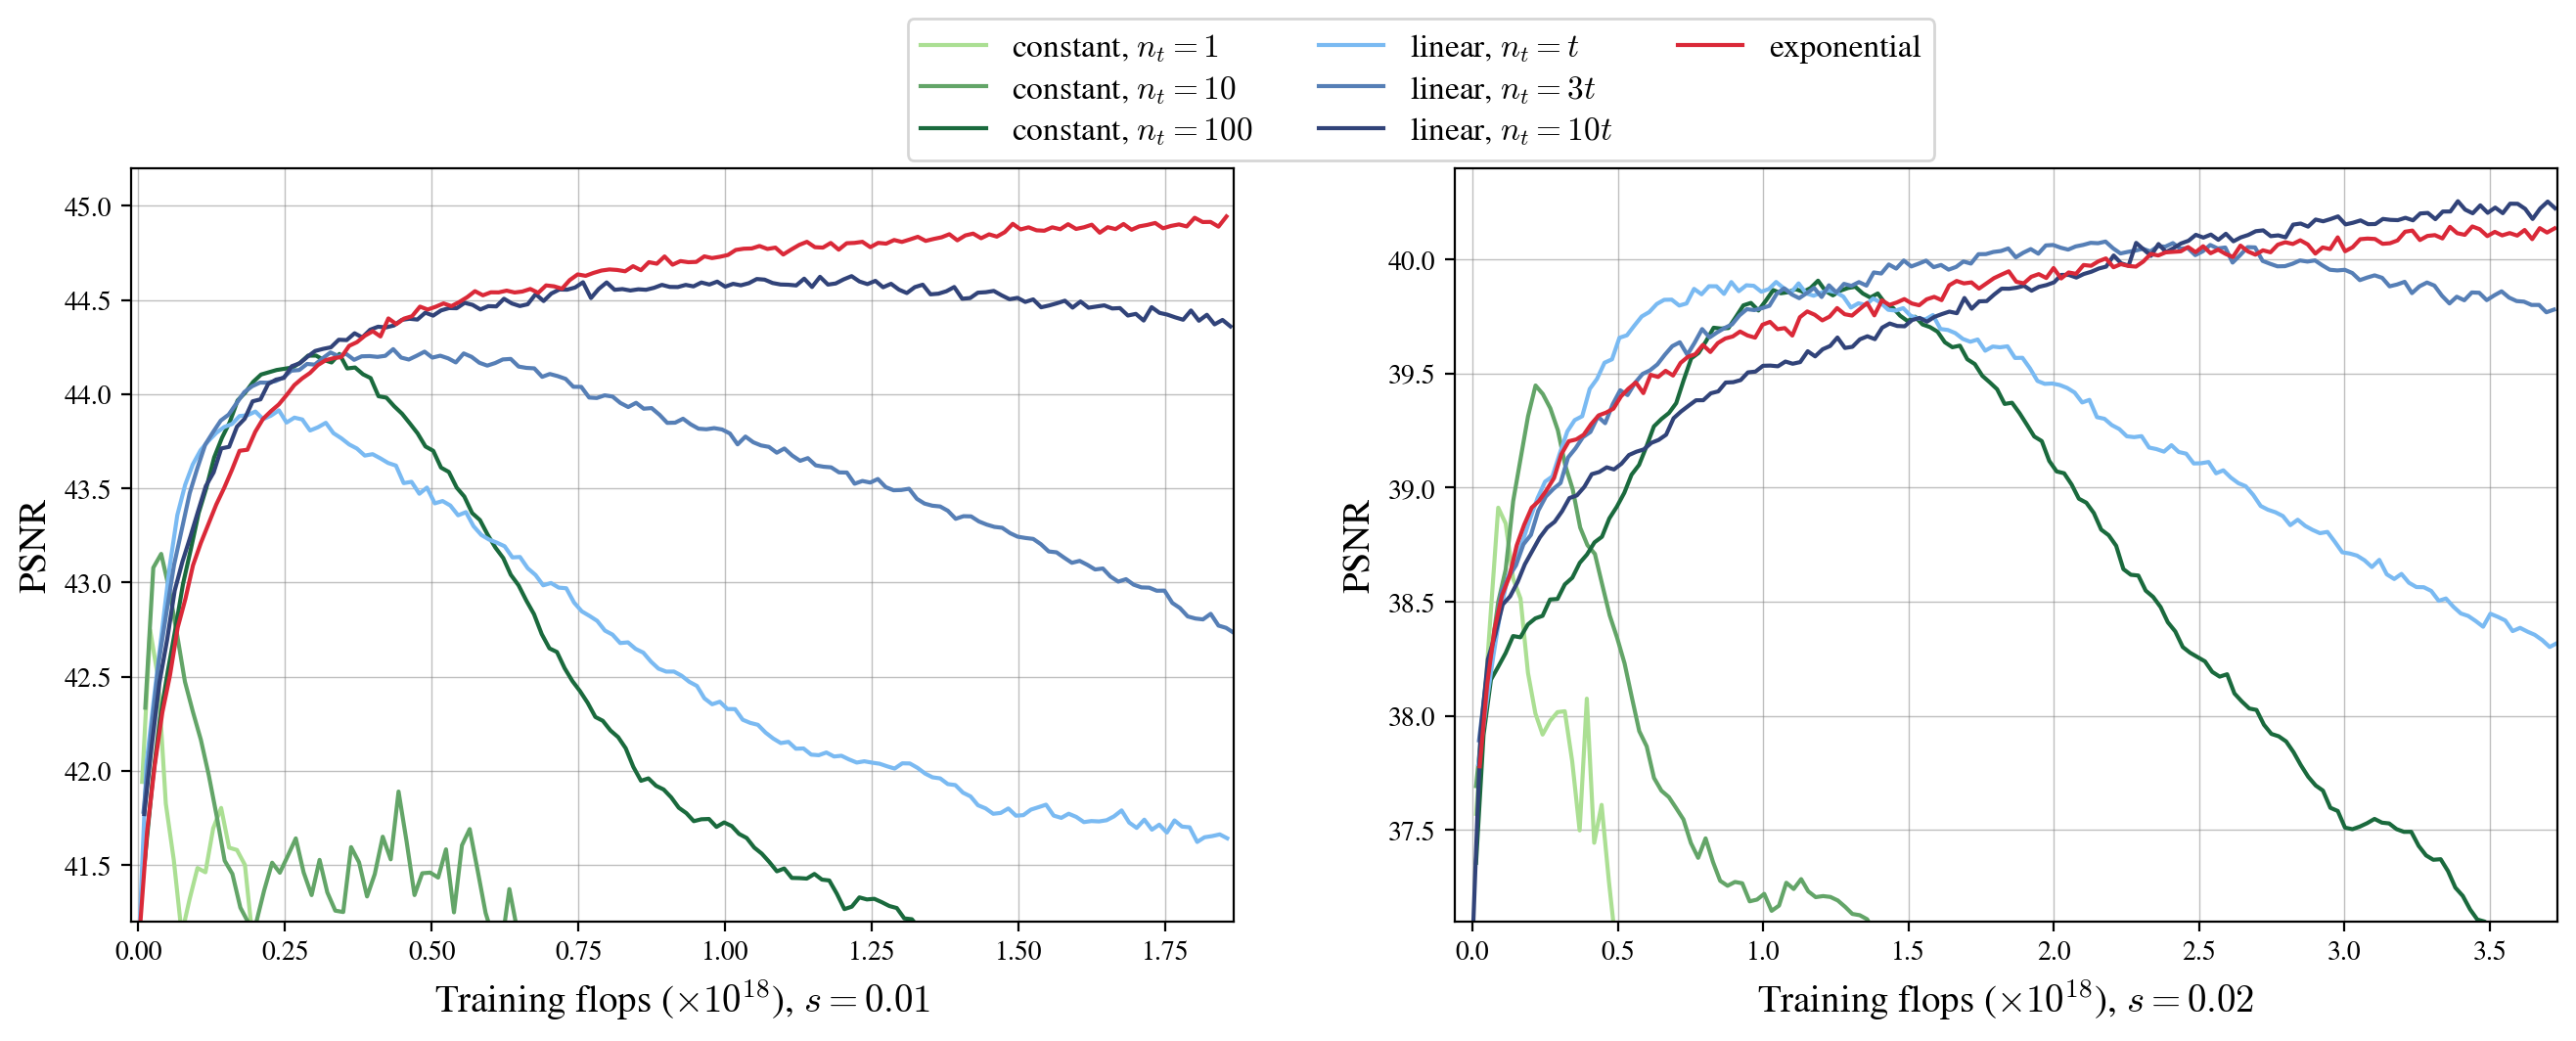

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

axs[0] = plot(axs[0], df1, exp_names1)
axs[1] = plot(axs[1], df2, exp_names2)

axs[0].set_xlabel(r'Training flops ($\times10^{18}$), $s=0.01$')
axs[1].set_xlabel(r'Training flops ($\times10^{18}$), $s=0.02$')
axs[0].set_ylim(41.2, 45.2)
axs[0].set_xlim(-1e6 * FLOPS_PER_INFER / flops_scale, 1.5e8 * FLOPS_PER_INFER / flops_scale)
axs[1].set_ylim(37.1, 40.4)
axs[1].set_xlim(-5e6 * FLOPS_PER_INFER / flops_scale,
                3e8 * FLOPS_PER_INFER / flops_scale)

axs[0].get_legend().set_visible(False)
handles, labels = axs[1].get_legend_handles_labels()
print(handles)
print(labels)

label_map = {
    'constant_N0=1': r'constant, $n_t=1$',
    'constant_N0=10': r'constant, $n_t=10$',
    'constant_N0=100': r'constant, $n_t=100$',
    'linear_N0=1_inc=1.0': r'linear, $n_t=t$',
    'linear_N0=1_inc=3.0': r'linear, $n_t=3t$',
    'linear_N0=1_inc=10.0': r'linear, $n_t=10t$',
    'exponential_N0=100_base=1.05': r'exponential',
    'exponential_N0=1_base=1.05': r'exponential',
}
labels = [label_map[label] for label in labels]
handles.append(matplotlib.lines.Line2D([0], [0], color='w', linewidth=1, linestyle='-'))
labels.append('   ')
axs[1].legend(handles=handles, labels=labels, loc='upper right',
              labelspacing=.3, 
              bbox_to_anchor=(.45, 1.22), ncol=3,
              prop={'size': 12})


/tmp/ipykernel_2071465/1782265066.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'constant'].sort_values('N0'),
/tmp/ipykernel_2071465/1782265066.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'linear'].sort_values('inc'),
/tmp/ipykernel_2071465/1782265066.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'exponential'].sort_values('N0'),
/tmp/ipykernel_2071465/1782265066.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'constant'].sort_values('N0'),
/tmp/ipykernel_2071465/1782265066.py:6: UserWarning: Boolean Series key will be reindexed to match DataFra

[<matplotlib.lines.Line2D object at 0x7fdfcc235390>, <matplotlib.lines.Line2D object at 0x7fdfcc22d650>, <matplotlib.lines.Line2D object at 0x7fdfcc3d1d50>, <matplotlib.lines.Line2D object at 0x7fdfcc2085d0>, <matplotlib.lines.Line2D object at 0x7fdfcc255450>, <matplotlib.lines.Line2D object at 0x7fdfcc26c850>, <matplotlib.lines.Line2D object at 0x7fdfcc3bc9d0>]
['constant_N0=1', 'constant_N0=10', 'constant_N0=100', 'linear_N0=1_inc=1.0', 'linear_N0=1_inc=3.0', 'linear_N0=1_inc=10.0', 'exponential_N0=1_base=1.05']


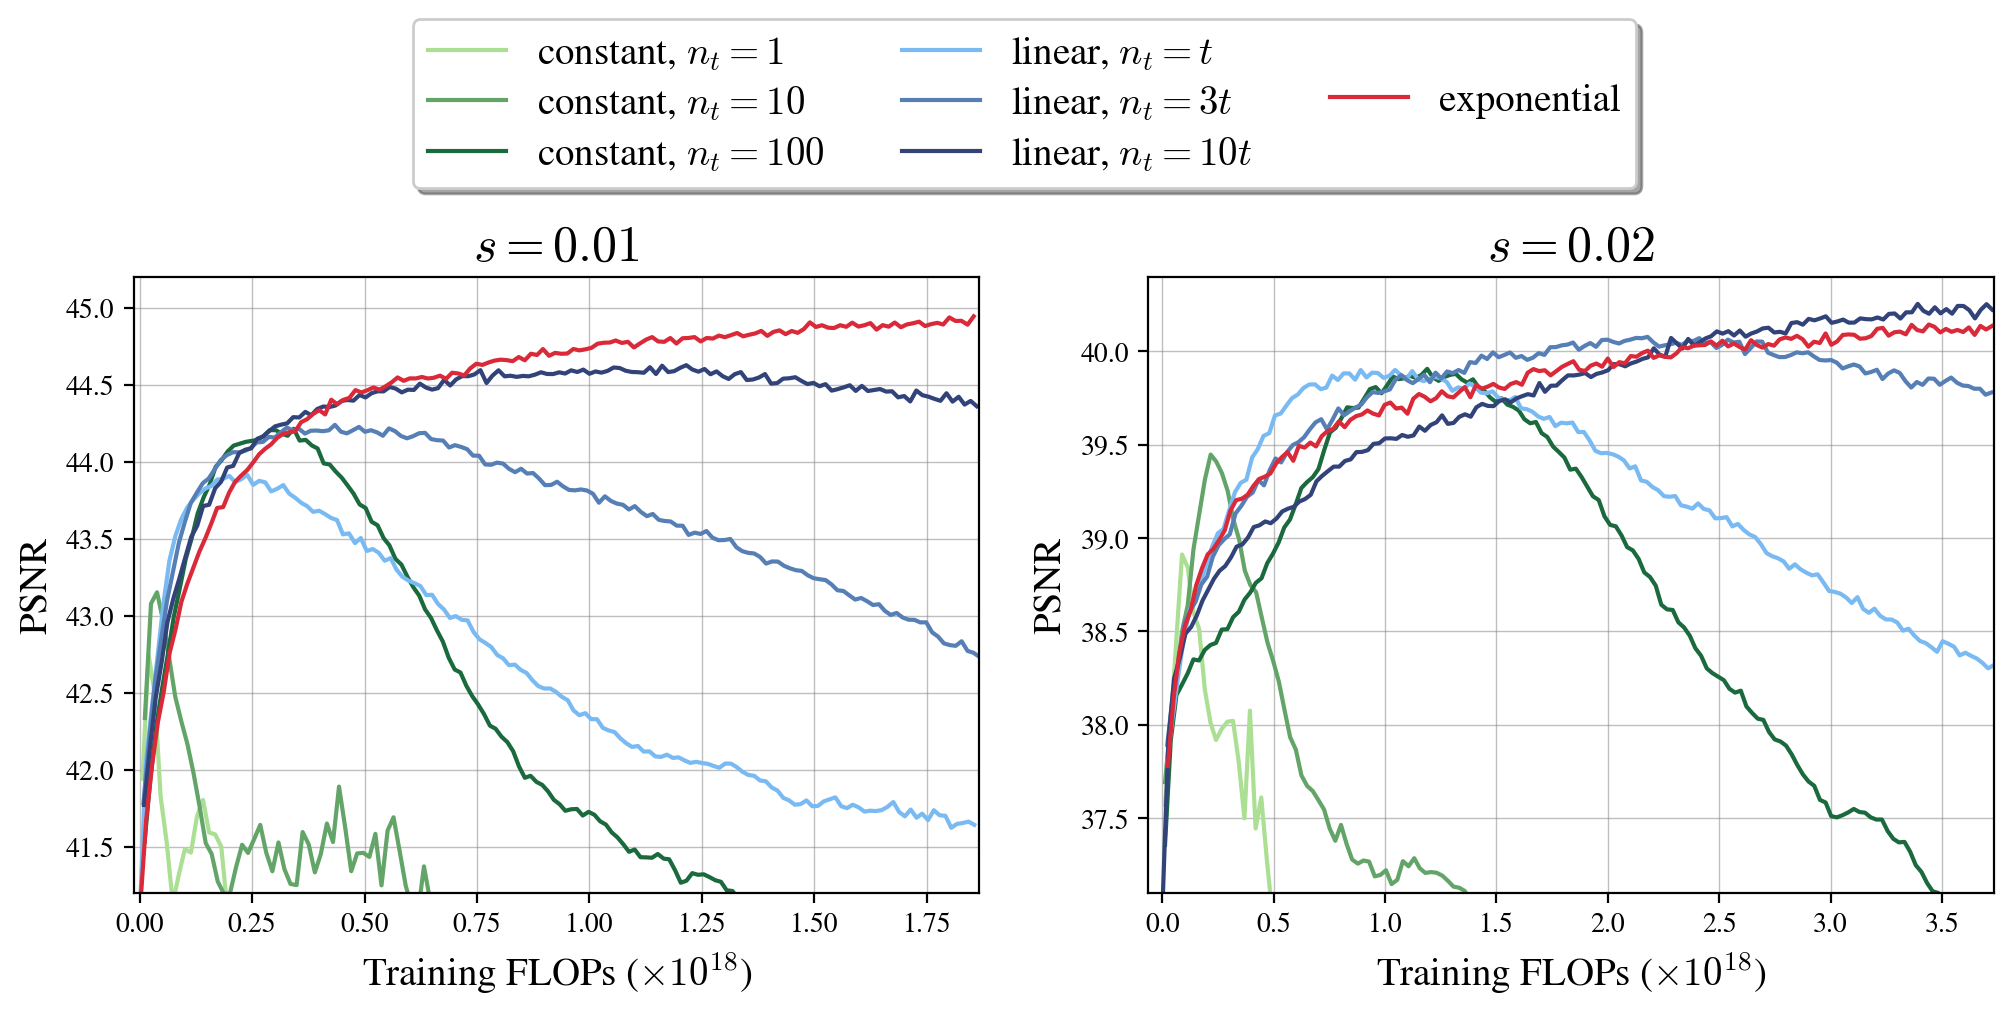

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0] = plot(axs[0], df1, exp_names1)
axs[1] = plot(axs[1], df2, exp_names2)

axs[0].set_title(r'$s=0.01$', fontsize=18)
axs[1].set_title(r'$s=0.02$', fontsize=18)
axs[0].set_ylim(41.2, 45.2)
axs[0].set_xlim(-1e6 * FLOPS_PER_INFER / flops_scale, 1.5e8 * FLOPS_PER_INFER / flops_scale)
axs[1].set_ylim(37.1, 40.4)
axs[1].set_xlim(-5e6 * FLOPS_PER_INFER / flops_scale,
                3e8 * FLOPS_PER_INFER / flops_scale)

axs[0].get_legend().set_visible(False)
handles, labels = axs[1].get_legend_handles_labels()
print(handles)
print(labels)

label_map = {
    'constant_N0=1': r'constant, $n_t=1$',
    'constant_N0=10': r'constant, $n_t=10$',
    'constant_N0=100': r'constant, $n_t=100$',
    'linear_N0=1_inc=1.0': r'linear, $n_t=t$',
    'linear_N0=1_inc=3.0': r'linear, $n_t=3t$',
    'linear_N0=1_inc=10.0': r'linear, $n_t=10t$',
    'exponential_N0=100_base=1.05': r'exponential',
    'exponential_N0=1_base=1.05': r'exponential',
}
labels = [label_map[label] for label in labels]

handles.insert(-1, matplotlib.lines.Line2D([0], [0], color='w', linewidth=1, linestyle='-'))
labels.insert(-1, '   ')
axs[1].legend(handles=handles, labels=labels, loc='upper right',
              labelspacing=.3, shadow=True,
              bbox_to_anchor=(.6, 1.45), ncol=3,
              prop={'size': 14})
